In [ ]:
import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'xgboost', 'scikit-learn', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'imbalanced-learn',
    '--quiet'
])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

np.random.seed(42)

print('✅ All imports successful!')
print(f'   scikit-learn, xgboost, seaborn — ready')

✅ All imports successful!
   scikit-learn, xgboost, seaborn — ready


In [ ]:
# ── Option A: Upload directly in Colab ───────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # select heart_disease_dataset.csv
CSV_PATH = 'heart_disease_dataset.csv'

# ── Option B: Mount Google Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/heart_disease_dataset.csv'

# ── Option C: Local / already in working directory ───────────────────────────
CSV_PATH = 'heart_disease_dataset.csv'

TARGET_COL = 'target'
CLASS_NAMES = ['No Disease', 'Disease']

df = pd.read_csv(CSV_PATH)
print(f'Dataset shape : {df.shape}')
print(f'Target counts :')
print(df[TARGET_COL].value_counts().rename({0:'No Disease',1:'Disease'}).to_string())
df.head()

Saving heart_disease_dataset.csv to heart_disease_dataset (2).csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape : (1000, 14)
Target counts :
target
No Disease    540
Disease       460


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,0,0,127,206,0,0,181,0,0.0,2,2,3,1
1,57,1,2,120,225,1,0,157,0,0.3,1,0,3,0
2,43,1,0,125,235,0,0,149,1,1.3,2,0,3,1
3,71,0,0,138,246,0,1,141,0,2.1,2,0,2,1
4,36,1,0,120,239,0,1,147,0,0.9,2,0,2,0


In [ ]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1000 non-null   int64  
 1   sex       1000 non-null   int64  
 2   cp        1000 non-null   int64  
 3   trestbps  1000 non-null   int64  
 4   chol      1000 non-null   int64  
 5   fbs       1000 non-null   int64  
 6   restecg   1000 non-null   int64  
 7   thalach   1000 non-null   int64  
 8   exang     1000 non-null   int64  
 9   oldpeak   1000 non-null   float64
 10  slope     1000 non-null   int64  
 11  ca        1000 non-null   int64  
 12  thal      1000 non-null   int64  
 13  target    1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB
None

=== Statistical Summary ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,53.38,0.48,0.96,131.28,244.44,0.14,0.51,149.11,0.33,1.09,1.38,0.71,2.30,0.46
std,14.12,0.50,1.02,16.60,50.54,0.35,0.53,23.08,0.47,1.07,0.63,0.99,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,73.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,41.00,0.00,0.00,120.00,208.00,0.00,0.00,133.00,0.00,0.30,1.00,0.00,2.00,0.00
50%,54.00,0.00,1.00,132.00,243.50,0.00,0.00,150.00,0.00,0.80,1.00,0.00,2.00,0.00
75%,65.00,1.00,2.00,143.00,281.00,0.00,1.00,165.25,1.00,1.50,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,190.00,394.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


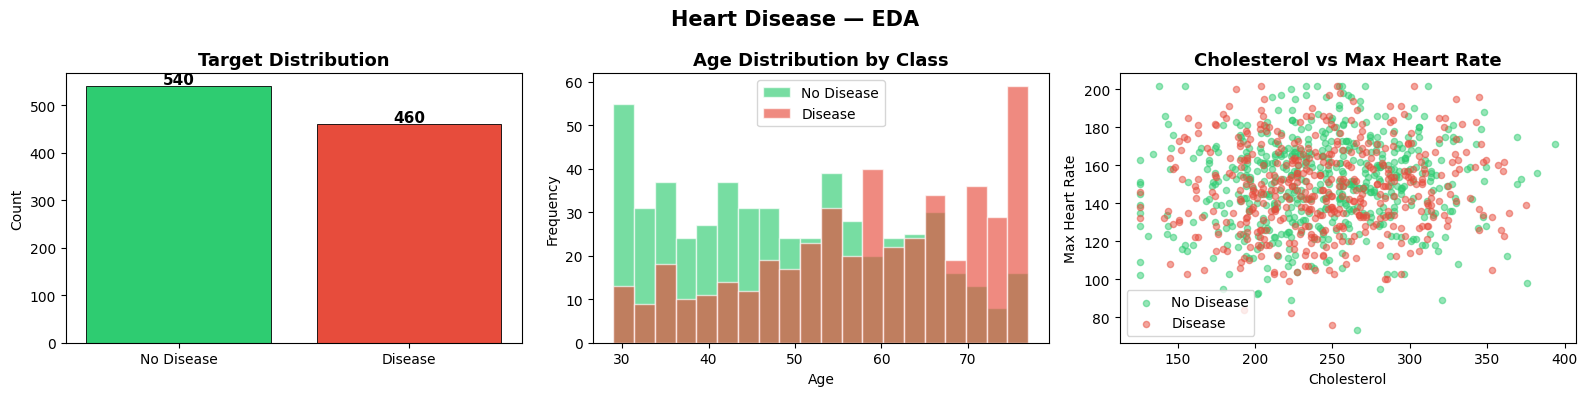

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution
counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar(CLASS_NAMES, counts.values, color=['#2ecc71','#e74c3c'],
            edgecolor='black', linewidth=0.6)
axes[0].set_title('Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=11, fontweight='bold')

# Age distribution by class
for cls, color, label in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Disease')]:
    axes[1].hist(df[df[TARGET_COL]==cls]['age'], bins=20, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[1].set_title('Age Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Frequency')
axes[1].legend()

# Cholesterol vs Max Heart Rate scatter
for cls, color, label in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Disease')]:
    sub = df[df[TARGET_COL]==cls]
    axes[2].scatter(sub['chol'], sub['thalach'], alpha=0.5,
                    c=color, label=label, s=20)
axes[2].set_title('Cholesterol vs Max Heart Rate', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Cholesterol'); axes[2].set_ylabel('Max Heart Rate')
axes[2].legend()

plt.suptitle('Heart Disease — EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

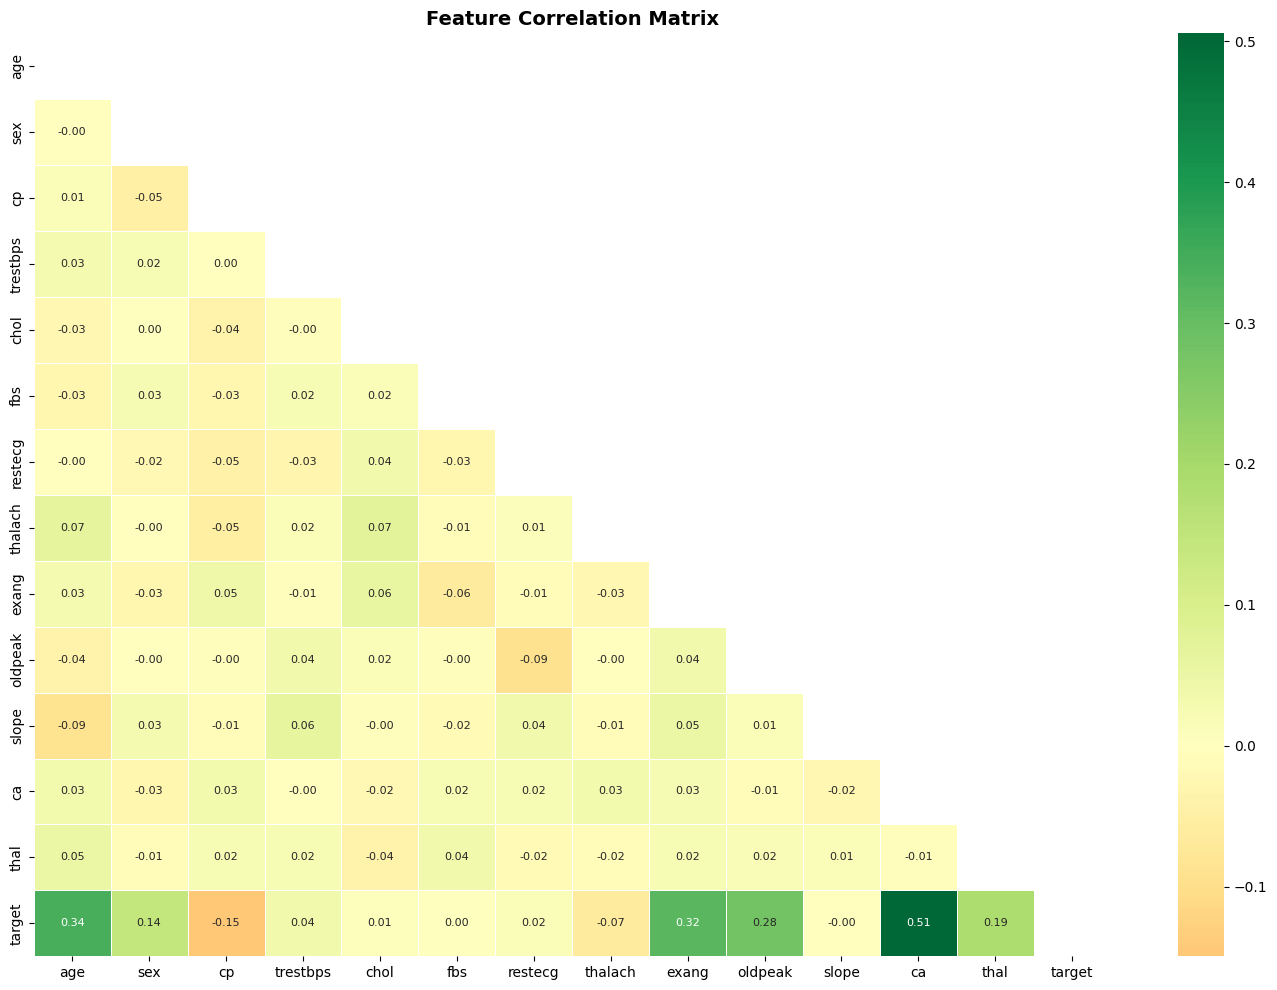

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

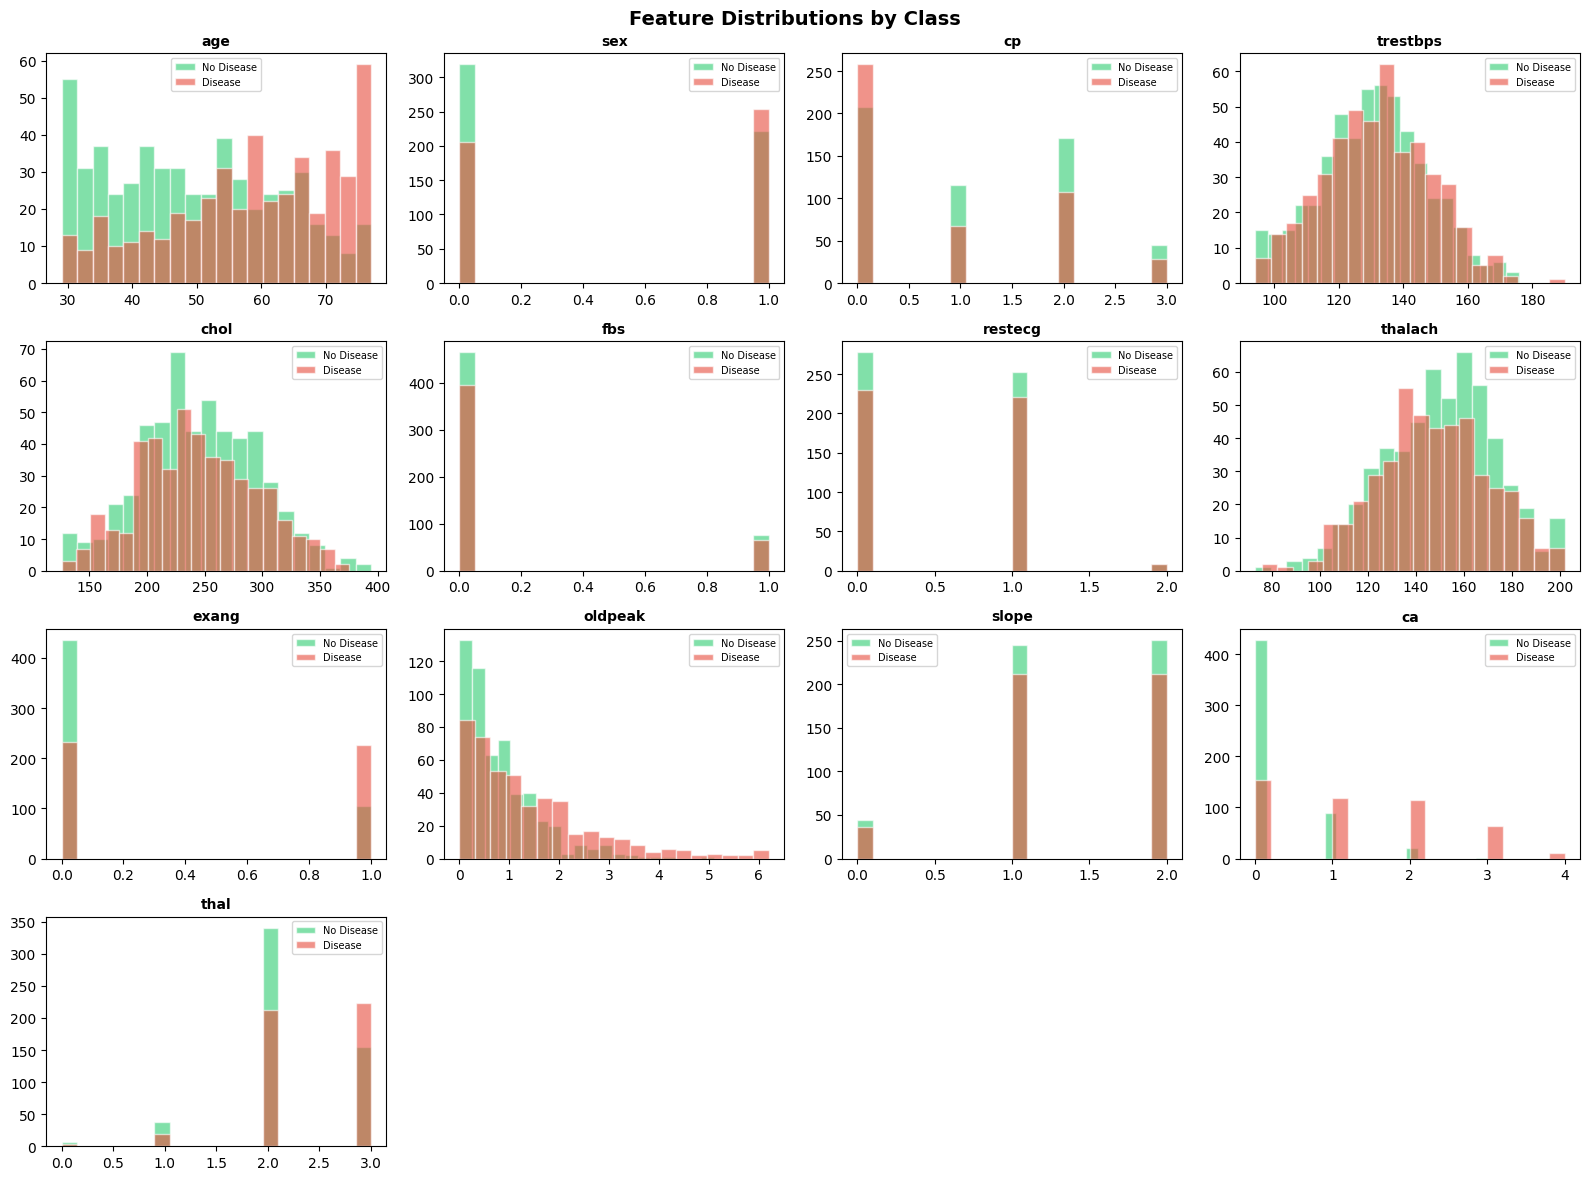

In [ ]:
# Feature distributions by target
num_features = [c for c in df.columns if c != TARGET_COL]
n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for cls, color, label in [(0,'#2ecc71','No Disease'),(1,'#e74c3c','Disease')]:
        axes[i].hist(df[df[TARGET_COL]==cls][feat], bins=20, alpha=0.6,
                     color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)

for i in range(len(num_features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train_s.shape}  |  Test : {X_test_s.shape}')
print(f'Train target balance: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test  target balance: {pd.Series(y_test).value_counts().to_dict()}')

Train : (800, 13)  |  Test : (200, 13)
Train target balance: {0: 432, 1: 368}
Test  target balance: {0: 108, 1: 92}


In [ ]:
models_dict = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   max_depth=8, min_samples_split=5),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1,
                                         max_depth=5, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42,
                                         verbosity=0)
}

results = {}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models_dict.items():
    clf.fit(X_train_s, y_train)
    y_pred  = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:, 1]
    cv_acc  = cross_val_score(clf, X_train_s, y_train, cv=cv,
                               scoring='accuracy').mean()
    results[name] = {
        'model'   : clf,
        'y_pred'  : y_pred,
        'y_proba' : y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_proba),
        'f1'      : f1_score(y_test, y_pred),
        'cv_acc'  : cv_acc
    }
    print(f'{name:22s} | Acc={results[name]["accuracy"]:.4f}  '
          f'AUC={results[name]["roc_auc"]:.4f}  '
          f'F1={results[name]["f1"]:.4f}  '
          f'CV={cv_acc:.4f}')

Logistic Regression    | Acc=0.9650  AUC=0.9948  F1=0.9617  CV=0.9475
SVM                    | Acc=0.9350  AUC=0.9890  F1=0.9282  CV=0.9287
Random Forest          | Acc=0.9250  AUC=0.9828  F1=0.9171  CV=0.8825
XGBoost                | Acc=0.9300  AUC=0.9849  F1=0.9231  CV=0.9088


=== Model Comparison ===
                     Accuracy  ROC-AUC  F1 Score  CV Acc
Logistic Regression     0.965   0.9948    0.9617  0.9475
SVM                     0.935   0.9890    0.9282  0.9288
Random Forest           0.925   0.9828    0.9171  0.8825
XGBoost                 0.930   0.9849    0.9231  0.9088


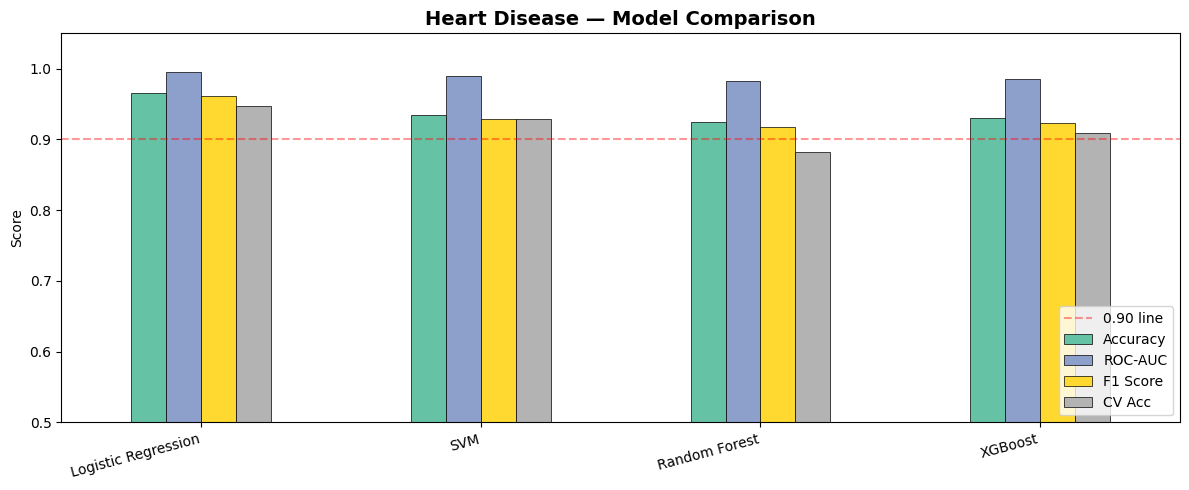

In [ ]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'ROC-AUC' : r['roc_auc'],
        'F1 Score': r['f1'],
        'CV Acc'  : r['cv_acc']
    } for name, r in results.items()
}).T.round(4)

print('=== Model Comparison ===')
print(metrics_df.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
metrics_df[['Accuracy','ROC-AUC','F1 Score','CV Acc']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5
)
ax.set_title('Heart Disease — Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0.5, 1.05])
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='0.90 line')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('heart_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

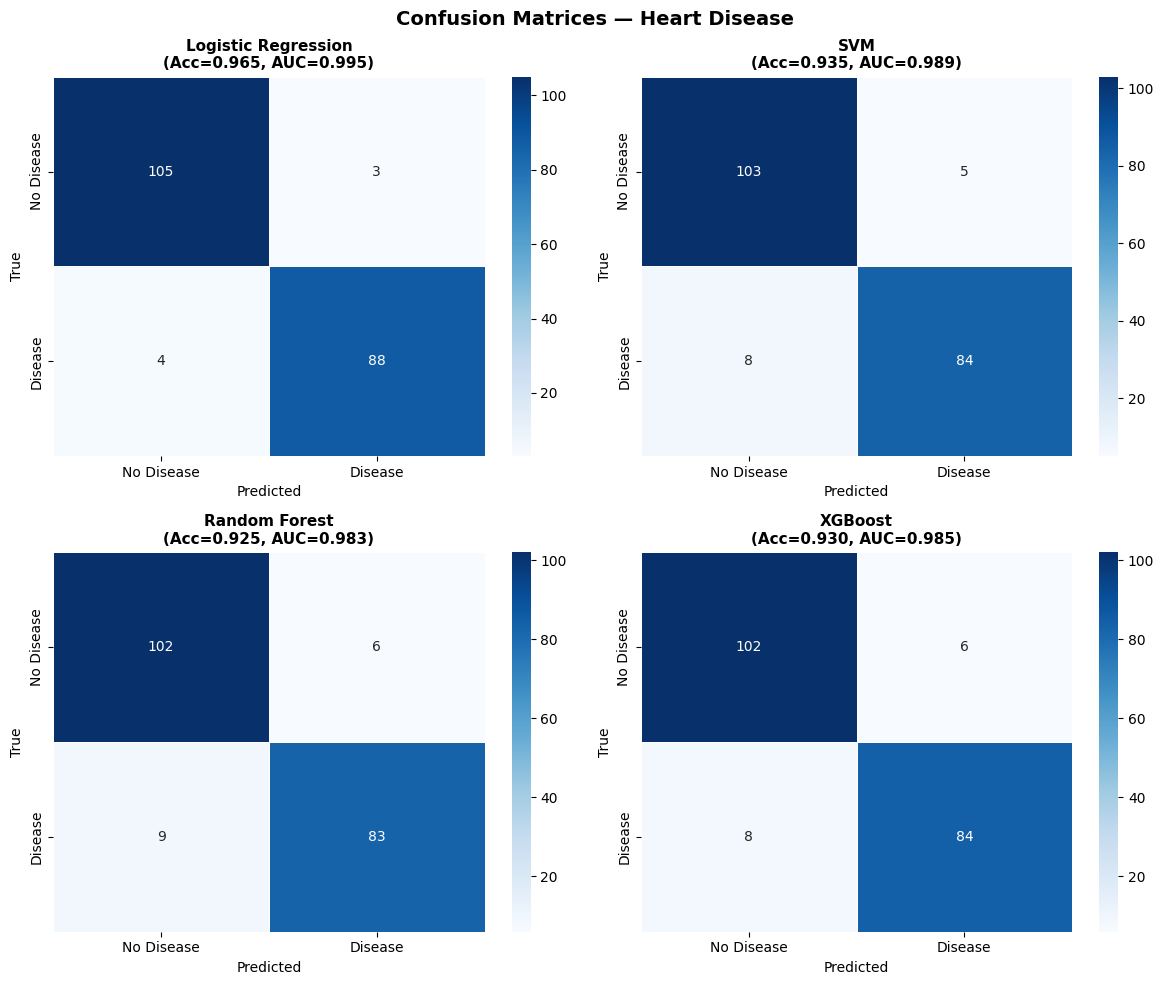

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=axes[i])
    axes[i].set_title(f'{name}\n(Acc={r["accuracy"]:.3f}, AUC={r["roc_auc"]:.3f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')

plt.suptitle('Confusion Matrices — Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

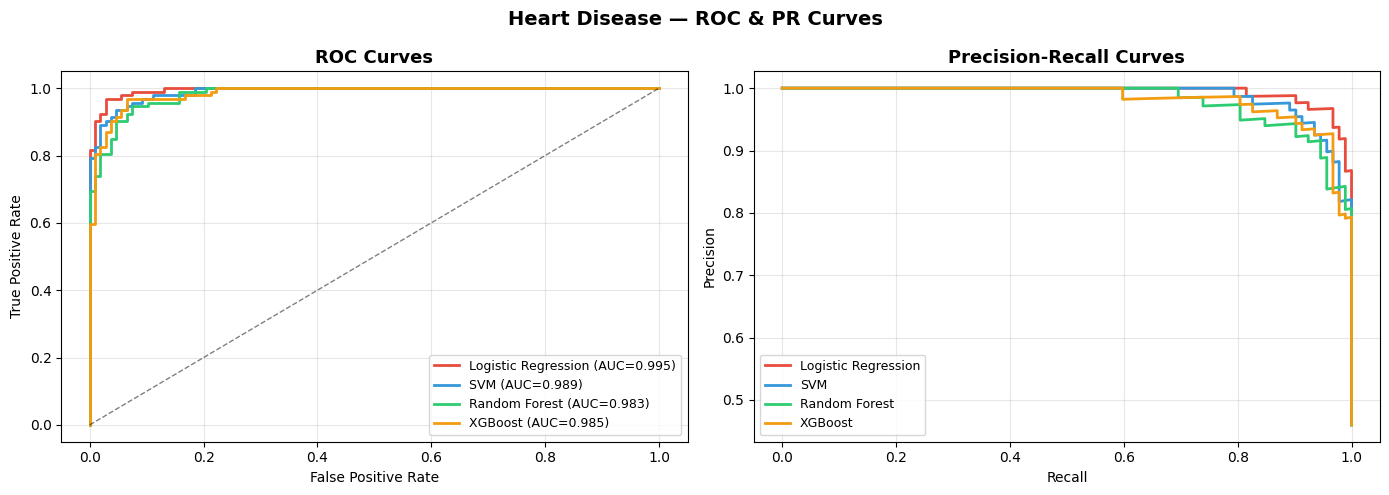

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']

# ROC curves
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={r["roc_auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Precision-Recall curves
for (name, r), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[1].plot(rec, prec, color=color, lw=2, label=name)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Heart Disease — ROC & PR Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

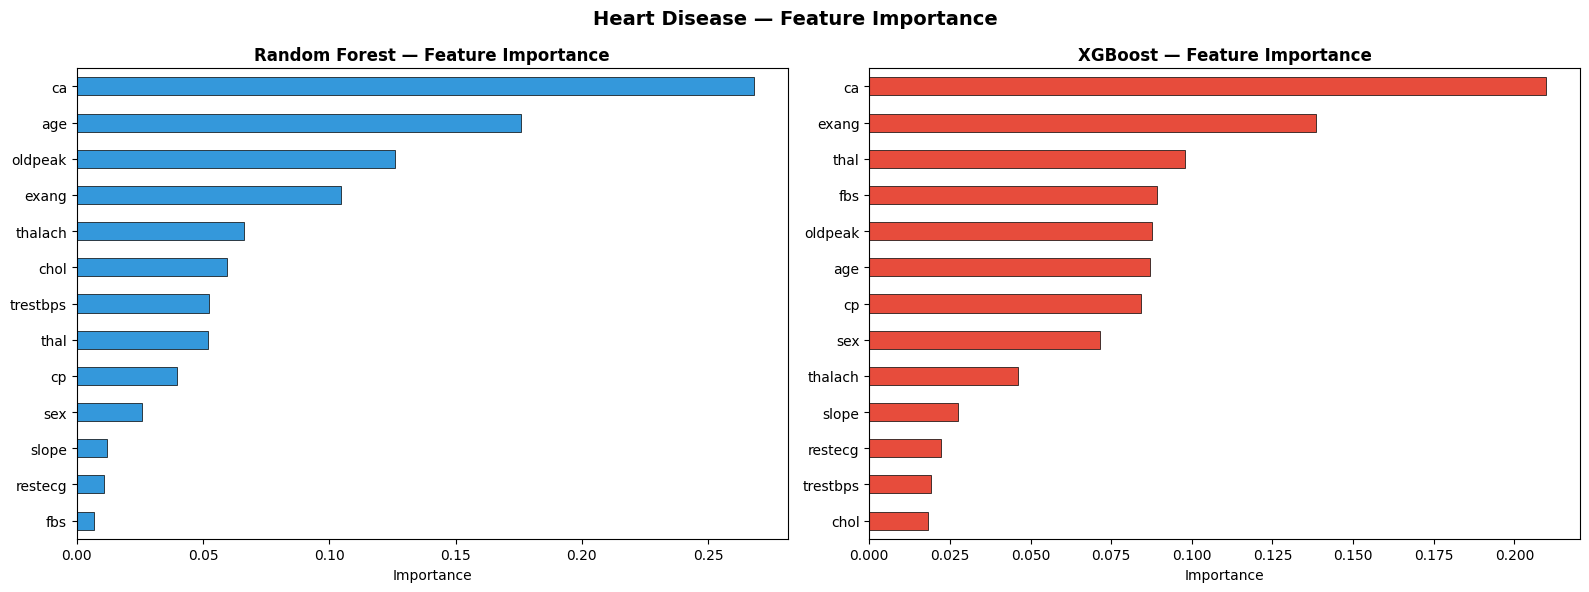

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest feature importance
rf_imp = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost feature importance
xgb_imp = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('XGBoost — Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Heart Disease — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
for name, r in results.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, r['y_pred'],
                                 target_names=CLASS_NAMES))


  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.96      0.97      0.97       108
     Disease       0.97      0.96      0.96        92

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200


  SVM
              precision    recall  f1-score   support

  No Disease       0.93      0.95      0.94       108
     Disease       0.94      0.91      0.93        92

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200


  Random Forest
              precision    recall  f1-score   support

  No Disease       0.92      0.94      0.93       108
     Disease       0.93      0.90      0.92        92

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93    

In [ ]:
# Column order: age, sex, cp, trestbps, chol, fbs, restecg,
#               thalach, exang, oldpeak, slope, ca, thal
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model      = results[best_model_name]['model']
print(f'Best model (by ROC-AUC): {best_model_name}')

new_patient = pd.DataFrame([{
    'age': 55, 'sex': 1, 'cp': 0, 'trestbps': 140,
    'chol': 250, 'fbs': 1, 'restecg': 1, 'thalach': 148,
    'exang': 1, 'oldpeak': 2.1, 'slope': 1, 'ca': 1, 'thal': 2
}])

new_scaled = scaler.transform(new_patient)
pred_class = best_model.predict(new_scaled)[0]
pred_prob  = best_model.predict_proba(new_scaled)[0]

print(f'\nPatient Input  : {new_patient.iloc[0].to_dict()}')
print(f'Prediction     : {CLASS_NAMES[pred_class]}  (label={pred_class})')
print(f'Confidence     : No Disease={pred_prob[0]:.2%}  Disease={pred_prob[1]:.2%}')

Best model (by ROC-AUC): Logistic Regression

Patient Input  : {'age': 55.0, 'sex': 1.0, 'cp': 0.0, 'trestbps': 140.0, 'chol': 250.0, 'fbs': 1.0, 'restecg': 1.0, 'thalach': 148.0, 'exang': 1.0, 'oldpeak': 2.1, 'slope': 1.0, 'ca': 1.0, 'thal': 2.0}
Prediction     : Disease  (label=1)
Confidence     : No Disease=0.01%  Disease=99.99%


In [ ]:
best = max(results, key=lambda k: results[k]['roc_auc'])
print('Heart Disease Prediction — Results Summary')
print('='*55)
for name, r in results.items():
    star = ' ← BEST' if name == best else ''
    print(f'  {name:22s}  AUC={r["roc_auc"]:.4f}  Acc={r["accuracy"]:.4f}{star}')
print('='*55)
print(f'Best Model : {best}')
print(f'Best AUC   : {results[best]["roc_auc"]:.4f}')

Heart Disease Prediction — Results Summary
  Logistic Regression     AUC=0.9948  Acc=0.9650 ← BEST
  SVM                     AUC=0.9890  Acc=0.9350
  Random Forest           AUC=0.9828  Acc=0.9250
  XGBoost                 AUC=0.9849  Acc=0.9300
Best Model : Logistic Regression
Best AUC   : 0.9948
